In [1]:
from google.colab import drive
from google.colab import files
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import os
os.chdir('/content/drive/MyDrive/IntroCienciaDatos/Semana6')
!ls

Datos  ProblemaClasificacion.ipynb  TratamientoImagenes.ipynb


In [3]:
# Paquetes básicos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Paquetes de ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import AUC as KerasAUC

In [4]:
df = pd.read_csv('Datos/Churn_Modelling.csv')

In [5]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [6]:
for col in ['RowNumber', 'CustomerId', 'Surname']:
  df.drop( col, axis=1, inplace=True )

In [7]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [8]:
# Queremos predecir si el cliente mantiene o no el producto
y = df['Exited'].astype(int)
x = df.drop(columns='Exited')

In [9]:
# one-hot econding
X = pd.get_dummies(x, drop_first=True)
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,True,False,True


<Axes: ylabel='Frequency'>

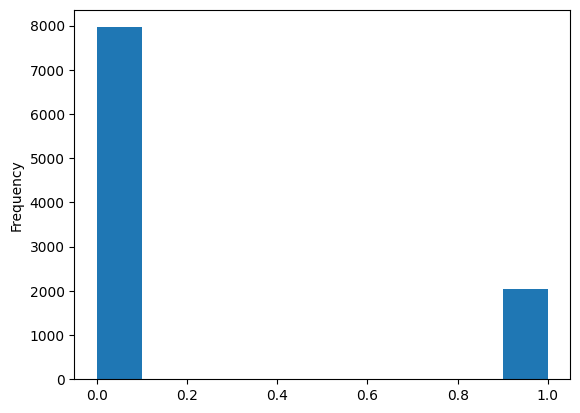

In [10]:
# Vamos entrenar un clasificador
# Esta balanceada la muestra
y.plot(kind = 'hist')

In [11]:
# La clases no están balanceadas -> Necesitamos realizar un remuestreo
X.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [13]:
# Vamos a balancear los datos
train = X_train.copy()
train['Exited'] = y_train.values

clase0 = train[ train['Exited'] == 0 ]
clase1 = train[ train['Exited'] == 1 ]

# El numero para remuestrear
n_min = len(clase1)
print(n_min)

clase_down = clase0.sample( n = n_min, random_state = 42 )

train_bal = pd.concat( [clase_down, clase1] ).sample(frac=1, random_state=42)

y_train = train_bal['Exited'].astype(int)
X_train = train_bal.drop(columns='Exited')

1630


(array([1630.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        1630.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

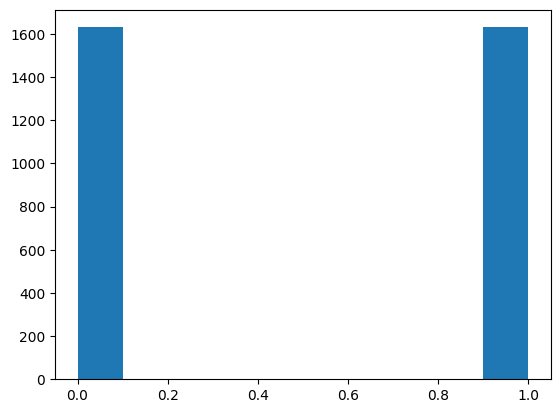

In [14]:
plt.hist(y_train.values)

In [15]:
# Vamos a escalar las variables
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [16]:
# Modelo basado en Keras
model = Sequential([
    Dense(30, activation='relu', input_shape=(X_train_s.shape[1],)),
    Dropout(0.2),
    Dense(30, activation='relu'),
    Dropout(0.2),
    Dense(20, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
# Compilamos el modelo
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', KerasAUC(name='auc')]
)

In [18]:
# Earlystopping
es = EarlyStopping(monitor='val_loss', patience=10, verbose=1, restore_best_weights=True)
history = model.fit(
    X_train_s, y_train,
    validation_split=0.2,
    batch_size=64,
    epochs=200,
    callbacks=[es],
    verbose=1
)

Epoch 1/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5460 - auc: 0.5629 - loss: 0.6941 - val_accuracy: 0.6626 - val_auc: 0.7290 - val_loss: 0.6366
Epoch 2/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6377 - auc: 0.6932 - loss: 0.6361 - val_accuracy: 0.6948 - val_auc: 0.7518 - val_loss: 0.6021
Epoch 3/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6741 - auc: 0.7306 - loss: 0.6130 - val_accuracy: 0.7086 - val_auc: 0.7704 - val_loss: 0.5813
Epoch 4/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6898 - auc: 0.7477 - loss: 0.5945 - val_accuracy: 0.7163 - val_auc: 0.7822 - val_loss: 0.5672
Epoch 5/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6975 - auc: 0.7582 - loss: 0.5912 - val_accuracy: 0.7163 - val_auc: 0.7910 - val_loss: 0.5563
Epoch 6/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7028 - auc: 0.7679 - loss: 0.5817 - val_accuracy: 0.7347 - val_auc: 0.8009 - val_loss: 0.5524
Epoch 7/200
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms

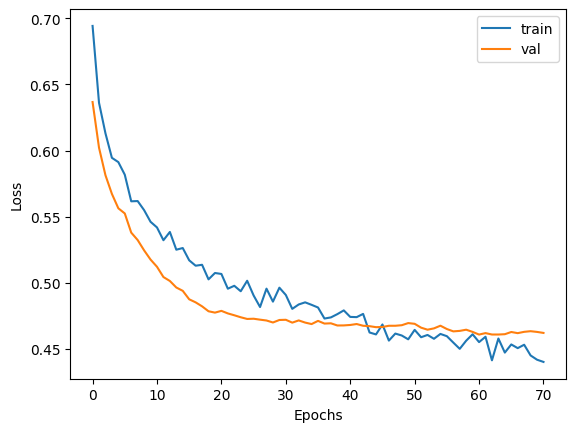

In [19]:
plt.figure()
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

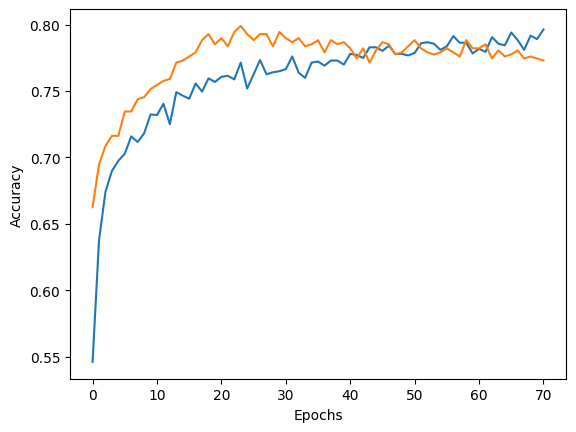

In [20]:
if 'accuracy' in history.history and 'val_accuracy' in history.history:
    plt.figure()
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='val')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend

In [21]:
# Vamos a estudiar otras metricas
y_prob = model.predict(X_test_s).ravel()
y_prob

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([0.07983246, 0.343588  , 0.16114469, ..., 0.9564568 , 0.09705011,
       0.21198066], dtype=float32)

In [22]:
# Vamos a construir la curva AUC
test_auc = roc_auc_score(y_test, y_prob)
print(test_auc)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

0.8644160339075593


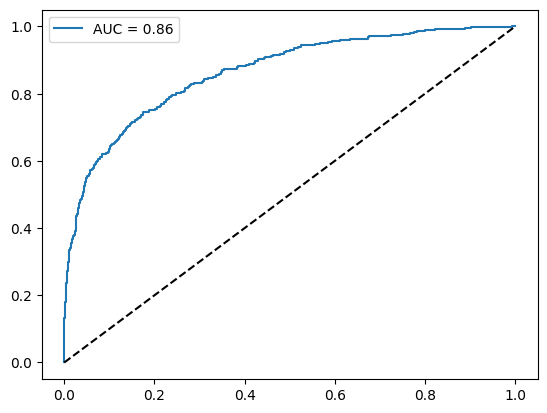

In [23]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure()
plt.plot(fpr, tpr, label='AUC = %0.2f' % test_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.legend()

In [24]:
model.predict(np.array([X_test_s[10,:]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


array([[0.8553149]], dtype=float32)

In [25]:
np.array([X_test_s[0,:]])

array([[-0.64713738, -0.47430174,  0.68929928, -1.32567431,  0.73225858,
         0.65274171, -0.93810774, -0.10465861, -0.65848097, -0.5551452 ,
         0.96443568]])

In [26]:
X_test.iloc[10,:]

,7068
CreditScore,699
Age,54
Tenure,3
Balance,111009.32
NumOfProducts,1
HasCrCard,1
IsActiveMember,1
EstimatedSalary,155905.79
Geography_Germany,True
Geography_Spain,False


In [27]:
y_test.iloc[10]

np.int64(1)

In [39]:
# Vamos a unbralizar el modelo
y_pred = ( y_prob >= 0.8 ).astype(int)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.78      0.48      0.60       407

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.76      2000
weighted avg       0.86      0.87      0.85      2000



<Axes: >

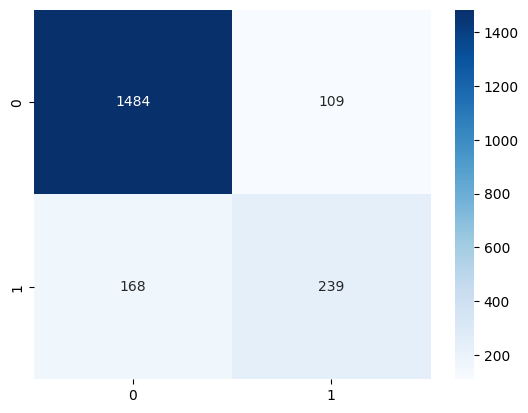

In [29]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')

In [31]:
# Vamos a estudiar la umbralización y como cambian las metricas


thresholds = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]

rows = []

for t in thresholds:

  y_pred = (y_prob >= t).astype(int)

  # matriz de confusion
  tn, fp, fn, tp = confusion_matrix(y_test,y_pred).ravel()

  print(tn,fp,fn,tp)
  # Metricas
  acc = (tp+tn)/(tp+tn+fp+fn)
  prec = tp / (tp + fp) if (tp + fp) > 0 else 0
  rec = tp / (tp + fn) if (tp + fn) > 0 else 0
  fpr_v = fp / (fp + tn) if (fp + tn) > 0 else 0
  f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0
  print(acc,prec,rec,fpr_v,f1)

  rows.append([t,acc,prec,rec,fpr_v,f1])

df_metrics = pd.DataFrame(rows)
df_metrics

305 1288 4 403
0.354 0.23832052040212892 0.9901719901719902 0.8085373509102323 0.3841754051477598
617 976 16 391
0.504 0.28602779809802487 0.9606879606879607 0.6126804770872567 0.4408117249154453
884 709 37 370
0.627 0.34291010194624655 0.9090909090909091 0.4450721908349027 0.49798115746971744
1073 520 62 345
0.709 0.3988439306358382 0.8476658476658476 0.32642812303829255 0.5424528301886792
1235 358 91 316
0.7755 0.4688427299703264 0.7764127764127764 0.22473320778405526 0.5846438482886216
1383 210 128 279
0.831 0.5705521472392638 0.6855036855036855 0.1318267419962335 0.6227678571428572
1484 109 168 239
0.8615 0.6867816091954023 0.5872235872235873 0.06842435655994979 0.633112582781457
1536 57 210 197
0.8665 0.7755905511811023 0.48402948402948404 0.035781544256120526 0.5960665658093797
1574 19 271 136
0.855 0.8774193548387097 0.33415233415233414 0.011927181418706842 0.48398576512455505


,0,1,2,3,4,5
0,0.1,0.3540,0.238321,0.990172,0.808537,0.384175
1,0.2,0.5040,0.286028,0.960688,0.612680,0.440812
2,0.3,0.6270,0.342910,0.909091,0.445072,0.497981
3,0.4,0.7090,0.398844,0.847666,0.326428,0.542453
4,0.5,0.7755,0.468843,0.776413,0.224733,0.584644
5,0.6,0.8310,0.570552,0.685504,0.131827,0.622768
6,0.7,0.8615,0.686782,0.587224,0.068424,0.633113
7,0.8,0.8665,0.775591,0.484029,0.035782,0.596067
8,0.9,0.8550,0.877419,0.334152,0.011927,0.483986


In [33]:


from sklearn.metrics import f1_score, confusion_matrix, precision_recall_curve

prec, rec, thr = precision_recall_curve(y_test, y_prob)
thr_all = np.concatenate(([0.0], thr, [1.0]))

f1_vals = []
for t in thr_all:
  y_pred = (y_prob >= t).astype(int)
  f1_vals.append(f1_score(y_test, y_pred, zero_division=0))



In [34]:
#¿Como encontramos el maximo?
best_idx = int( np.argmax(f1_vals) )
best_t = float(thr_all[best_idx])
best_f1 = float(f1_vals[best_idx])
print(best_t, best_f1)

0.6886695623397827 0.6373056994818653


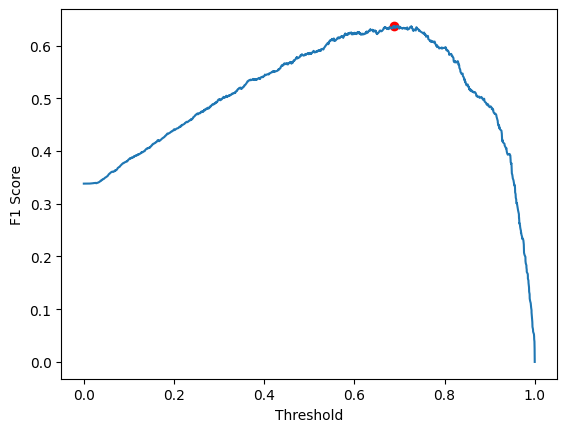

In [35]:


f1_vals = np.array(f1_vals)

plt.figure()
plt.plot(thr_all, f1_vals)
plt.scatter([best_t],[best_f1],color='r')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.show()



Confusion matrix, without normalization


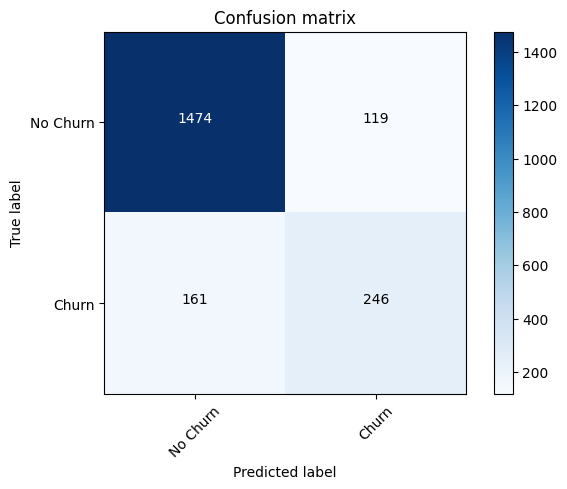

In [38]:

# Rutina para la matriz de confusion

import itertools
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
  plt.imshow(cm,interpolation='nearest',cmap=cmap)
  plt.title(title)
  plt.colorbar()
  tick_marks = np.arange(len(classes))
  plt.xticks(tick_marks,classes,rotation=45)
  plt.yticks(tick_marks,classes)

  if normalize:
    cm = cm.astype('float')/cm.sum(axis=1)[:,np.newaxis]
    print('Normalized confusion matrix')
  else:
    print('Confusion matrix, without normalization')
  #print(cm)

  thresh = cm.max()/2
  for i,j in itertools.product(range(cm.shape[0]),range(cm.shape[1])):
    plt.text(j,i,cm[i,j],
             horizontalalignment='center',
             color='white' if cm[i,j]>thresh else 'black')

  plt.tight_layout()
  plt.ylabel('True label')
  plt.xlabel('Predicted label')


cm = confusion_matrix(y_test, (y_prob >= best_t).astype(int))
plot_confusion_matrix(cm, classes=['No Churn', 'Churn'])

